# Pausa práctica 5 — Viendo un Barren Plateau en vivo

**Contexto:** acabamos de cerrar el bloque de Frontera 2025-2026, incluyendo Barren Plateaus, el fenómeno donde el gradiente de entrenamiento desaparece exponencialmente al crecer el número de qubits.

En este notebook lo medimos directamente: calculamos la **varianza del gradiente** de un circuito variacional al azar, para distintos números de qubits, y vemos cómo se desploma.

In [3]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp

estimator = Estimator()
np.random.seed(42)


## El experimento

Para cada número de qubits, generamos un circuito variacional con parámetros **al azar** (esto es clave: sin ningún preacondicionamiento, como el que vimos en la diapositiva anterior), y medimos qué tan sensible es la energía de salida a un pequeño cambio en el primer parámetro, eso es el gradiente.

In [5]:
def gradiente_muestra(n_qubits, n_muestras=40, epsilon=1e-2):
    """Estima la varianza del gradiente respecto al primer parametro.
    reps escala con n_qubits y el observable es GLOBAL (Z en todos los
    qubits) para que el efecto de barren plateau se vea con claridad."""
    reps = max(2, n_qubits // 2)
    ansatz = efficient_su2(n_qubits, reps=reps, entanglement="full")
    n_params = ansatz.num_parameters

    obs = SparsePauliOp("Z" * n_qubits)

    gradientes = []
    for _ in range(n_muestras):
        theta = np.random.uniform(-np.pi, np.pi, n_params)
        theta_plus = theta.copy()
        theta_plus[0] += epsilon

        e0 = estimator.run([(ansatz, obs, theta)]).result()[0].data.evs
        e1 = estimator.run([(ansatz, obs, theta_plus)]).result()[0].data.evs

        grad = (e1 - e0) / epsilon
        gradientes.append(grad)

    return np.var(gradientes)

qubit_range = [2, 4, 6, 8, 10, 12]
varianzas = [gradiente_muestra(n) for n in qubit_range]

for n, v in zip(qubit_range, varianzas):
    print(f"n = {n:2d} qubits  ->  varianza del gradiente = {v:.6e}")


n =  2 qubits  ->  varianza del gradiente = 9.671748e-02
n =  4 qubits  ->  varianza del gradiente = 1.401586e-02
n =  6 qubits  ->  varianza del gradiente = 1.113809e-02
n =  8 qubits  ->  varianza del gradiente = 1.233250e-03
n = 10 qubits  ->  varianza del gradiente = 4.271079e-04
n = 12 qubits  ->  varianza del gradiente = 8.925056e-05


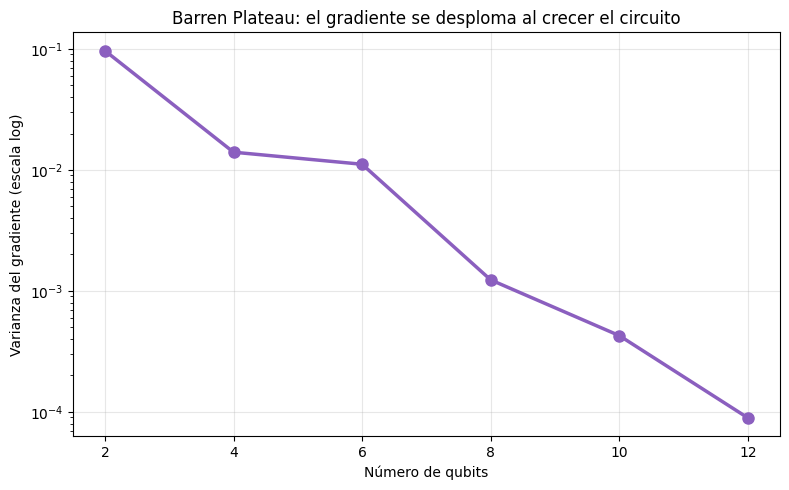

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(qubit_range, varianzas, marker="o", color="#8B5FBF", linewidth=2.5, markersize=8)
ax.set_yscale("log")
ax.set_xlabel("Número de qubits")
ax.set_ylabel("Varianza del gradiente (escala log)")
ax.set_title("Barren Plateau: el gradiente se desploma al crecer el circuito")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("barren_plateau.png", dpi=140)
plt.show()


Con parámetros aleatorios, la varianza del gradiente cae exponencialmente con el número de qubits — literalmente lo que la diapositiva anterior describía con la fórmula `→ 0`. A partir de cierto tamaño, ese gradiente es indistinguible del ruido estadístico, y el entrenamiento deja de funcionar sin importar cuánto tiempo le des.

**Por qué esto conecta con todo lo que vimos antes:** es exactamente la razón por la que técnicas como el preacondicionamiento cuántico (la historia de 1 día → 1 hora → 3 minutos) importan tanto, no es solo "más rápido", es evitar caer en esta trampa desde el diseño del algoritmo, no después de que el entrenamiento ya falló.